In [19]:
import pandas as pd 
import os
import time

def load_user_session(folder_path):
    
    def load_sensor_file(filepath):
        df = pd.read_csv(filepath, sep="\t")

        df.columns = df.columns.str.strip()
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='ms')

        df = df.dropna(subset=['Timestamp'])

        # transforms the timestamp into ms from first timestamp
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
        df['Timestamp'] = round(df['Timestamp'].astype('int64') / 1e6)

        first_timestamp = df['Timestamp'].iloc[0]
        df['Timestamp'] = df['Timestamp'] - first_timestamp
        
        # rename columns
        df = df.rename(columns={'Timestamp': 'timestamp', 'X': 'acc_x', 'Y': 'acc_y', 'Z': 'acc_z'})


        
        
        return df

    sensors = {}
    
    file_path = os.path.join(folder_path, "accelerometer.txt")
    if os.path.exists(file_path):
        sensors = load_sensor_file(file_path)

    
    return sensors


In [24]:


from json import load


raw_data_path = '../data/mendeley-Cristiana-Gabriel/datasets'

parsed_data_path = '../data/mendeley-Cristiana-Gabriel/parsed/'

time_start = time.perf_counter()
idx = 0

folders_to_parse = [f for f in os.listdir(raw_data_path) if os.path.isdir(os.path.join(raw_data_path, f))]

nr_folders_to_parse = len(folders_to_parse)
for foldername in folders_to_parse:

    full_path = os.path.join(raw_data_path, foldername)
    
    if idx % 5 == 0:
        print(f"Processed {idx}/{nr_folders_to_parse} folders")
        current_time = time.perf_counter()
        print(f"Elapsed: {current_time - time_start:.6f} s")

    idx += 1
    data = load_user_session(full_path)

    parsed_file_path = os.path.join(parsed_data_path, f'{idx}.csv')
    data.to_csv(parsed_file_path, index=False)


time_end = time.perf_counter()
print("All done!")
print(f"Total: {time_end - time_start:.6f} s")


Processed 0/208 folders
Elapsed: 0.003060 s
Processed 5/208 folders
Elapsed: 0.033435 s
Processed 10/208 folders
Elapsed: 0.069478 s
Processed 15/208 folders
Elapsed: 0.091854 s
Processed 20/208 folders
Elapsed: 0.111343 s
Processed 25/208 folders
Elapsed: 0.132809 s
Processed 30/208 folders
Elapsed: 0.151511 s
Processed 35/208 folders
Elapsed: 0.168265 s
Processed 40/208 folders
Elapsed: 0.187595 s
Processed 45/208 folders
Elapsed: 0.212051 s
Processed 50/208 folders
Elapsed: 0.274369 s
Processed 55/208 folders
Elapsed: 0.305033 s
Processed 60/208 folders
Elapsed: 0.319653 s
Processed 65/208 folders
Elapsed: 0.359651 s
Processed 70/208 folders
Elapsed: 0.379810 s
Processed 75/208 folders
Elapsed: 0.396331 s
Processed 80/208 folders
Elapsed: 0.426692 s
Processed 85/208 folders
Elapsed: 0.450800 s
Processed 90/208 folders
Elapsed: 0.477152 s
Processed 95/208 folders
Elapsed: 0.590189 s
Processed 100/208 folders
Elapsed: 0.609643 s
Processed 105/208 folders
Elapsed: 0.630773 s
Processed 

Presenting the first 5 resulting gyroscope data

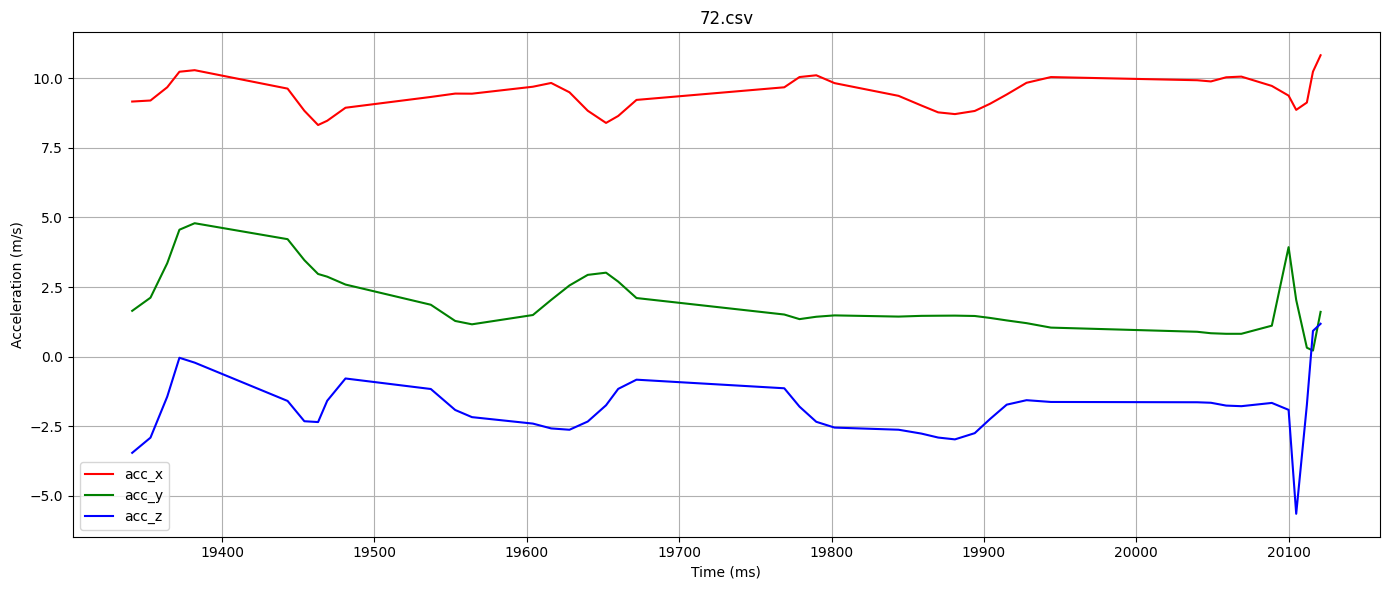

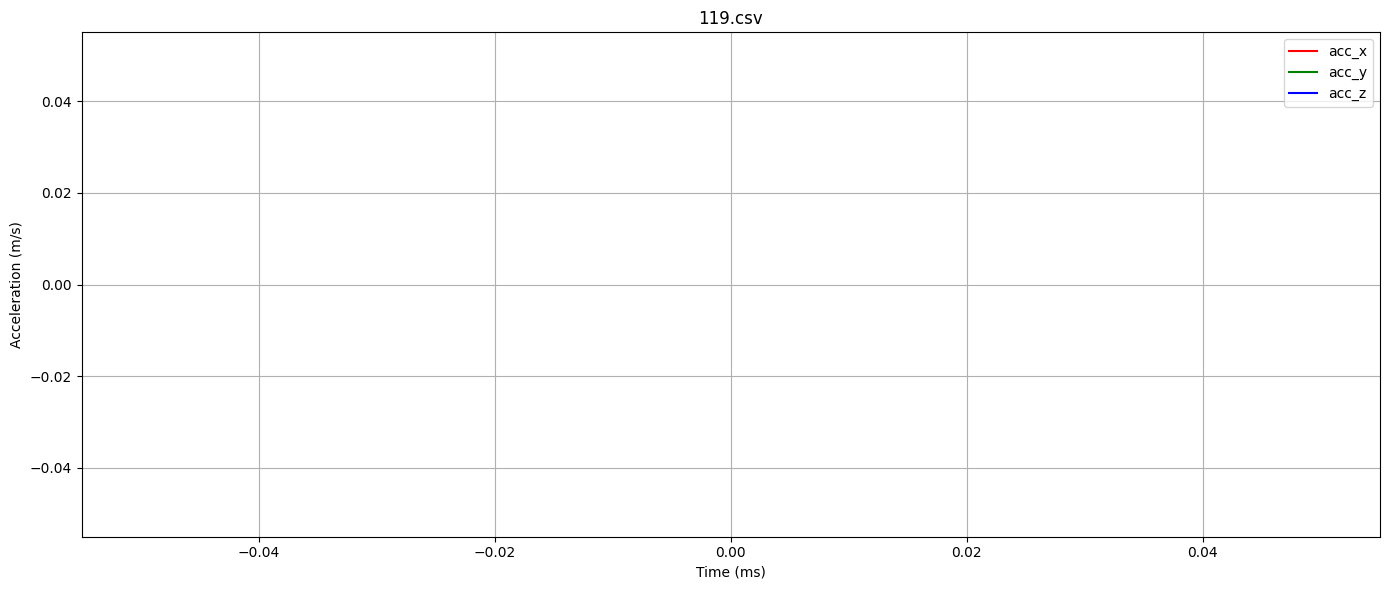

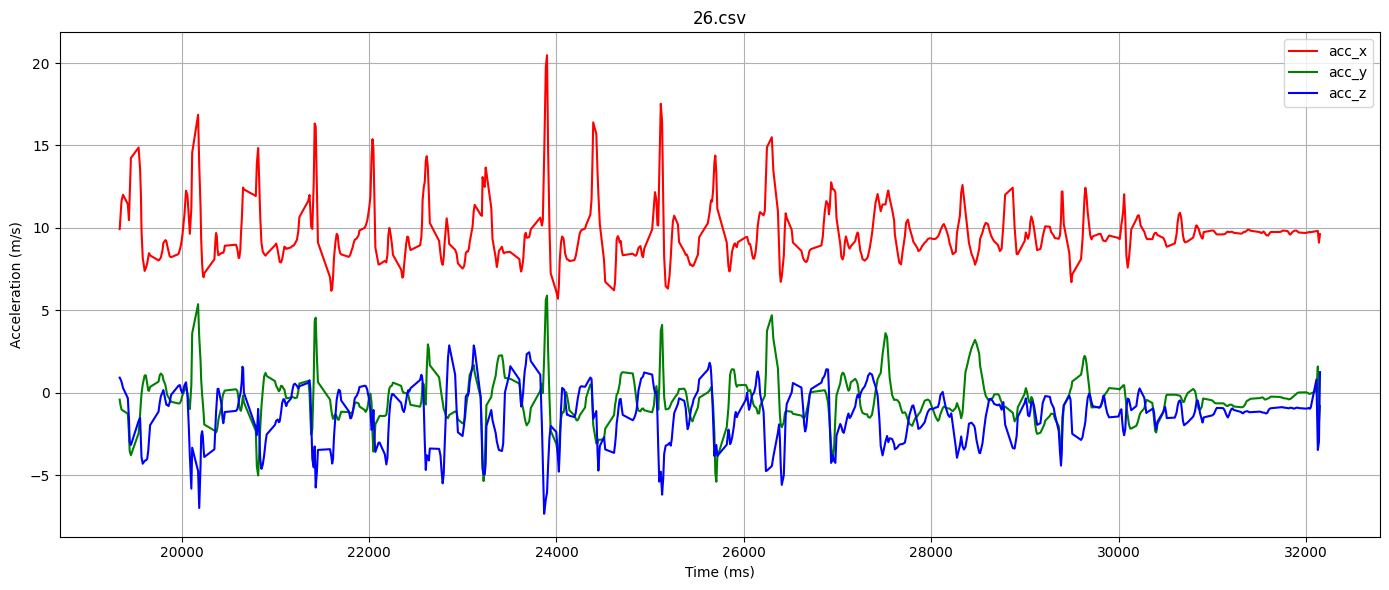

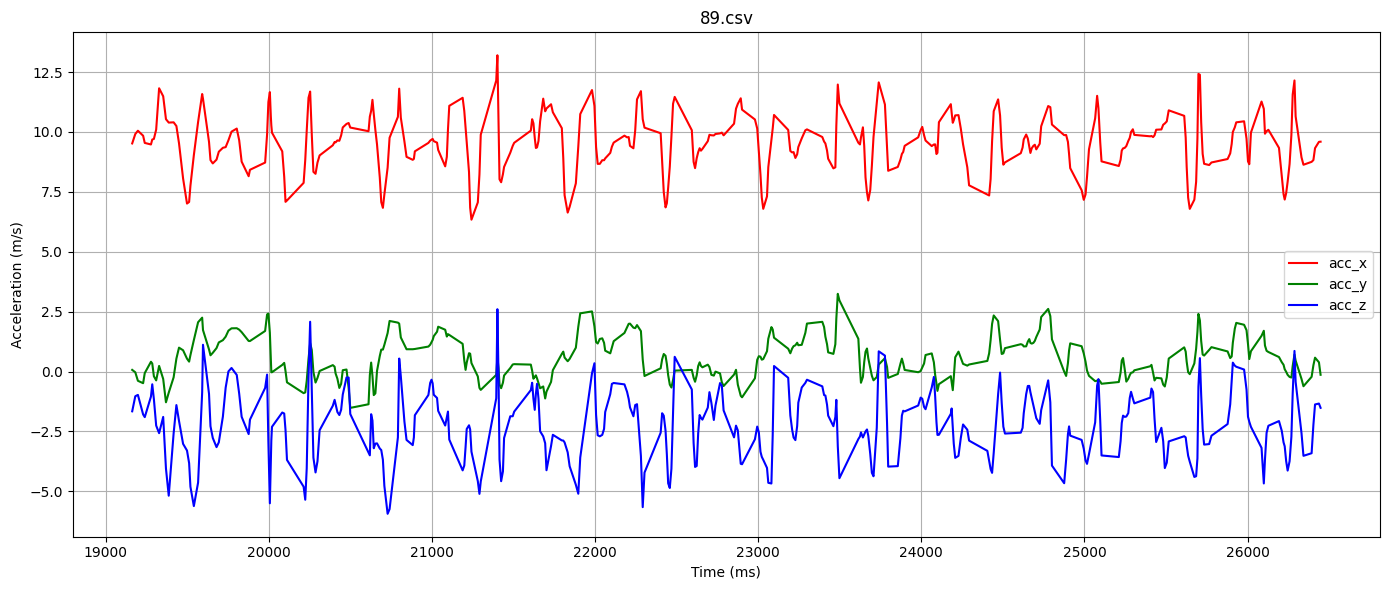

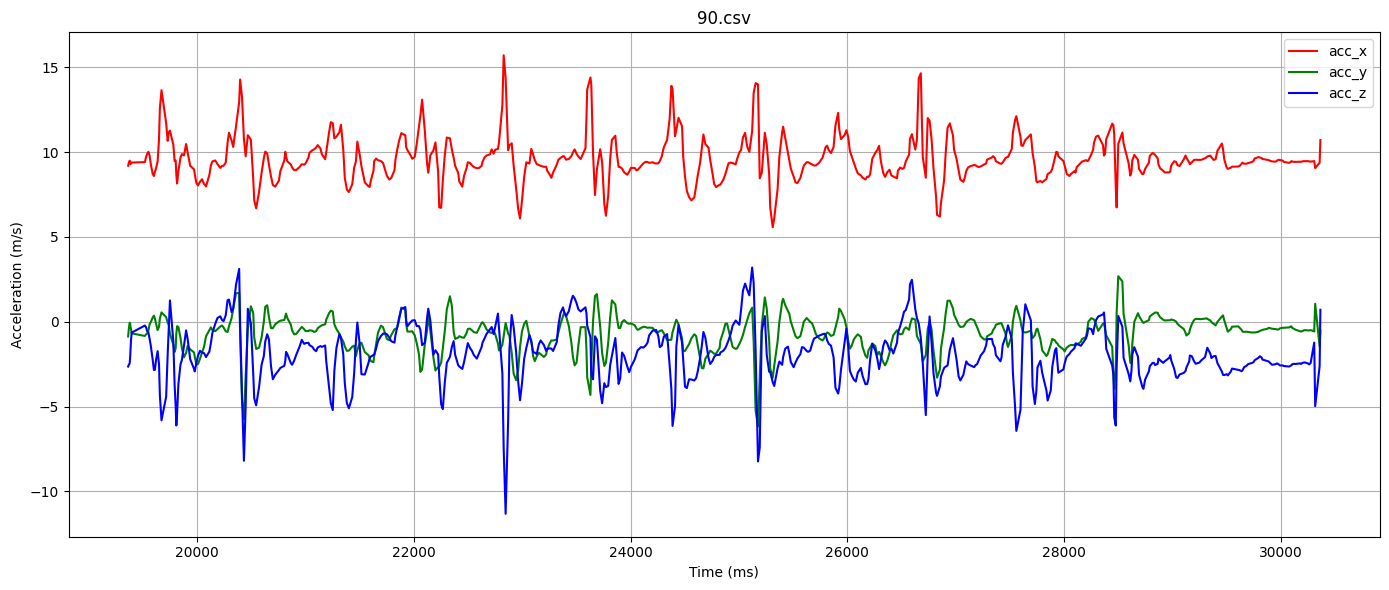

In [25]:
import matplotlib.pyplot as plt 

parsed_data_path = '../data/mendeley-Cristiana-Gabriel/parsed'

files_to_print = [f for f in os.listdir(parsed_data_path) if (os.path.isfile(os.path.join(parsed_data_path, f)) and os.path.splitext(os.path.join(parsed_data_path, f))[1] == '.csv')]
files_to_print = files_to_print[5:10]
COLORS = {
    'acc_x': 'r',
    'acc_y': 'g',
    'acc_z': 'b'
}

for filename in files_to_print:
    csv_data = pd.read_csv(os.path.join(parsed_data_path, filename)) 

    csv_data = csv_data[1000:2000]

    plt.figure(figsize=(14,6))

    

    for axis in ['acc_x', 'acc_y', 'acc_z']:
        plt.plot(csv_data['timestamp'], csv_data[axis], label=f'{axis}', color=COLORS[axis])

    plt.title(filename)
    plt.xlabel('Time (ms)')
    plt.ylabel('Acceleration (m/s)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


https://arxiv.org/pdf/1801.02336

We will perform the operations presented in the paper on part 1 data collection 

1. Computing average magnitude

In [26]:


files_to_print = [f for f in os.listdir(parsed_data_path) if (os.path.isfile(os.path.join(parsed_data_path, f)) and os.path.splitext(os.path.join(parsed_data_path, f))[1] == '.csv')]

files_to_modify = files_to_print

mag_reduced_data_path = '../data/mendeley-Cristiana-Gabriel/parsed_mag_reduced'

import numpy as np

for filename in files_to_modify:
    csv_data = pd.read_csv(os.path.join(parsed_data_path, filename)) 

    csv_data['magnitude'] = np.sqrt(csv_data['acc_x']**2 + csv_data['acc_y']**2 + csv_data['acc_z']**2)

    avg_magnitude = csv_data['magnitude'].mean()

    csv_data['magnitude'] = csv_data['magnitude'] - avg_magnitude

    csv_data = csv_data.drop(['acc_x', 'acc_y', 'acc_z'], axis=1)

    csv_data.to_csv(os.path.join(mag_reduced_data_path, filename), index=False)

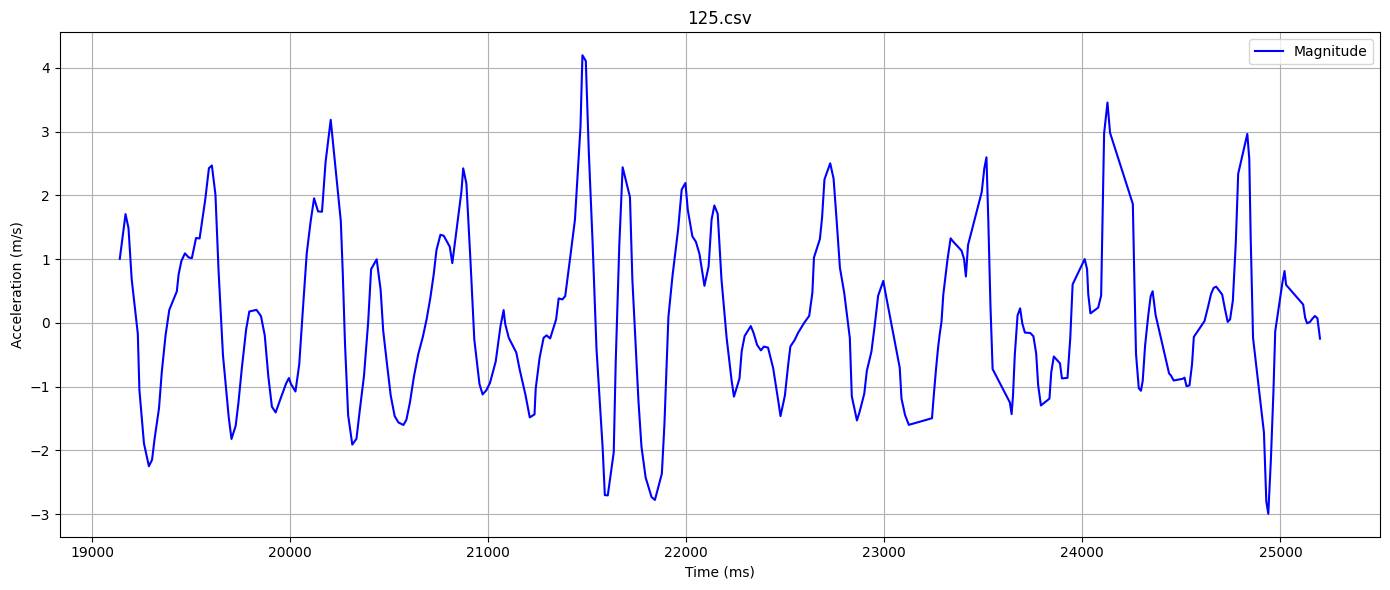

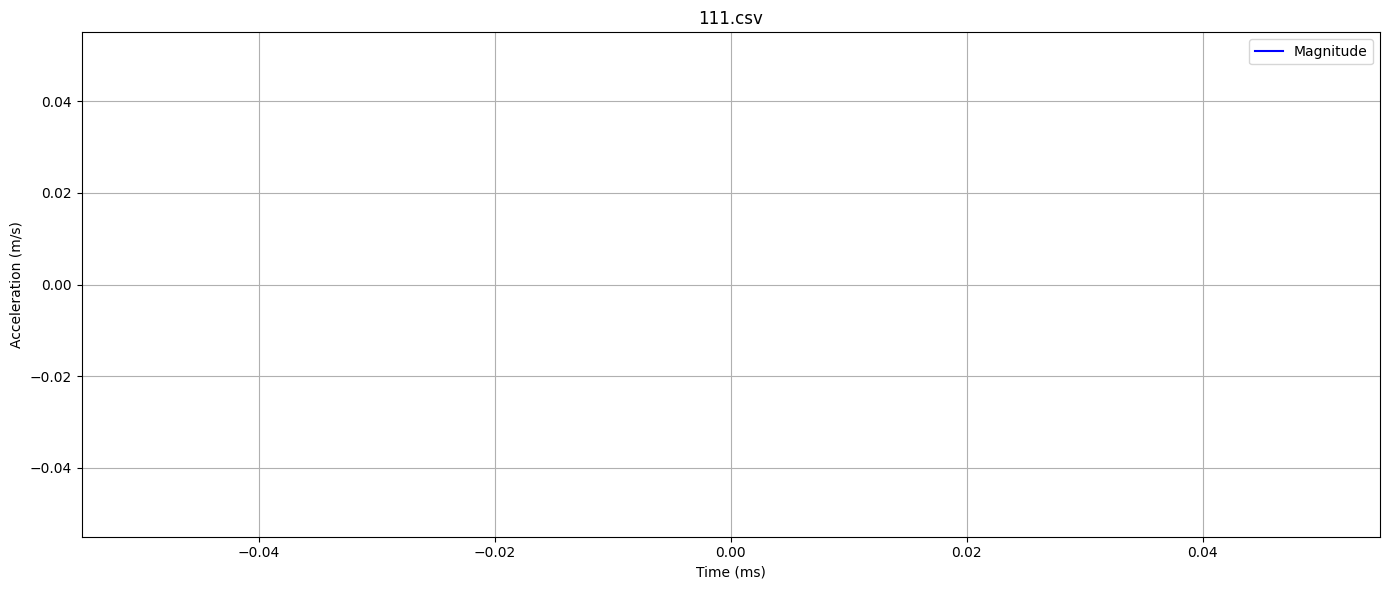

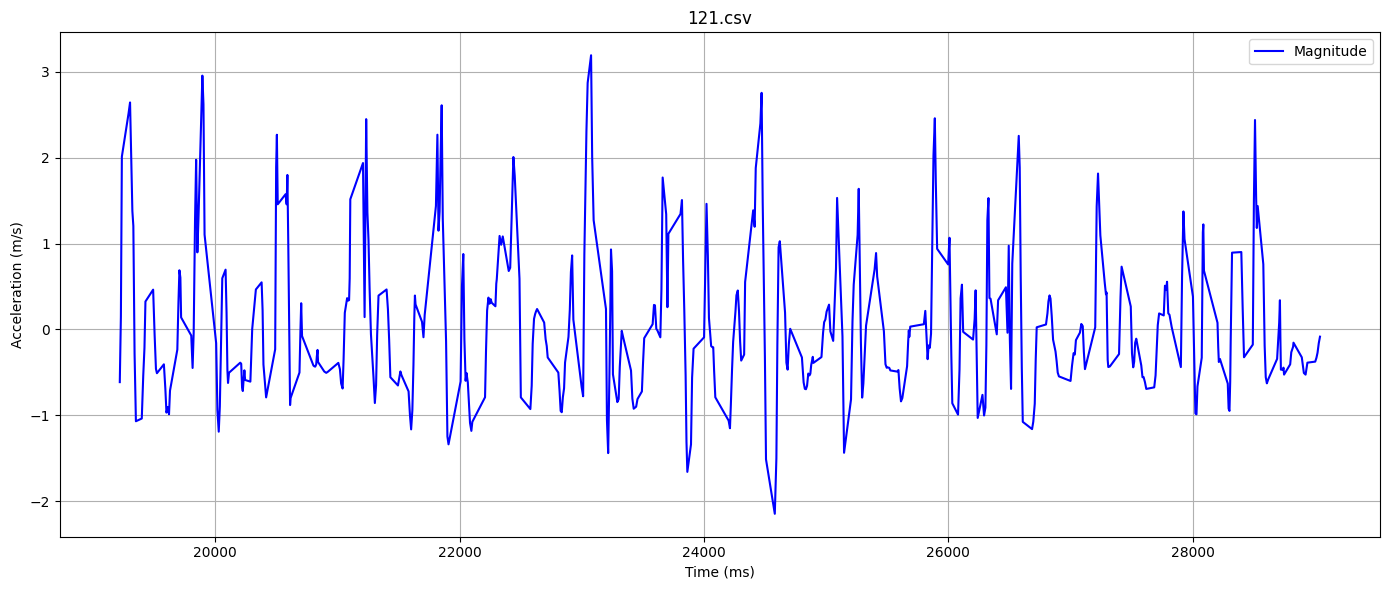

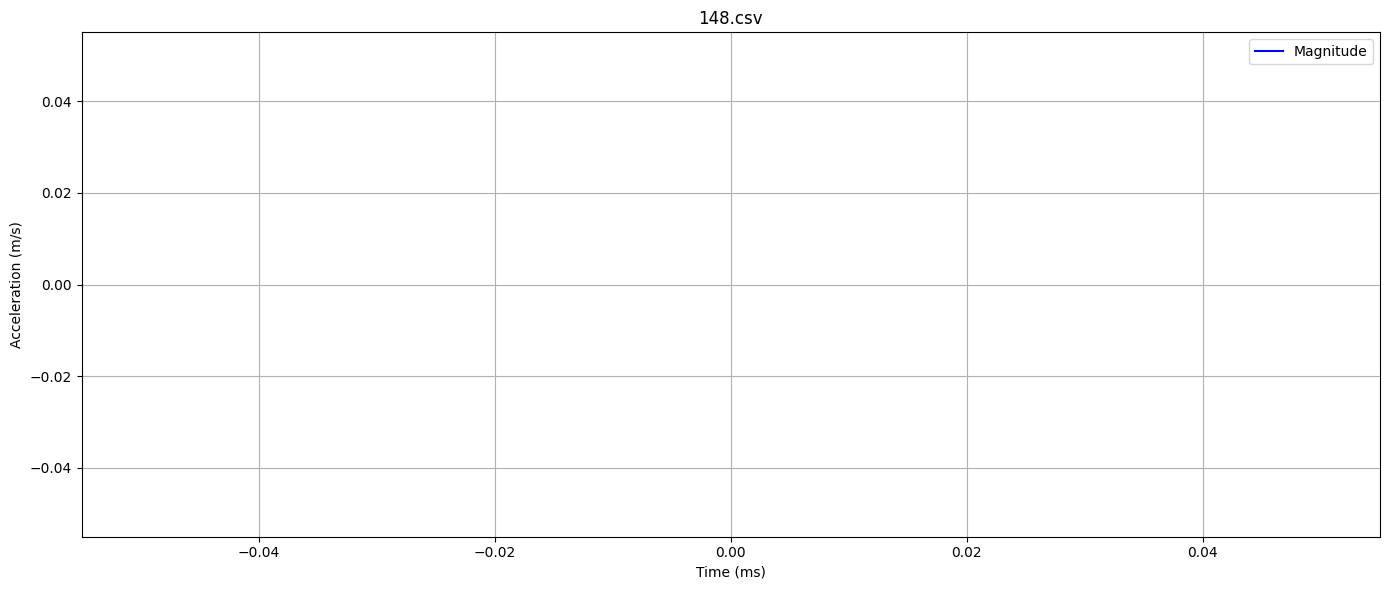

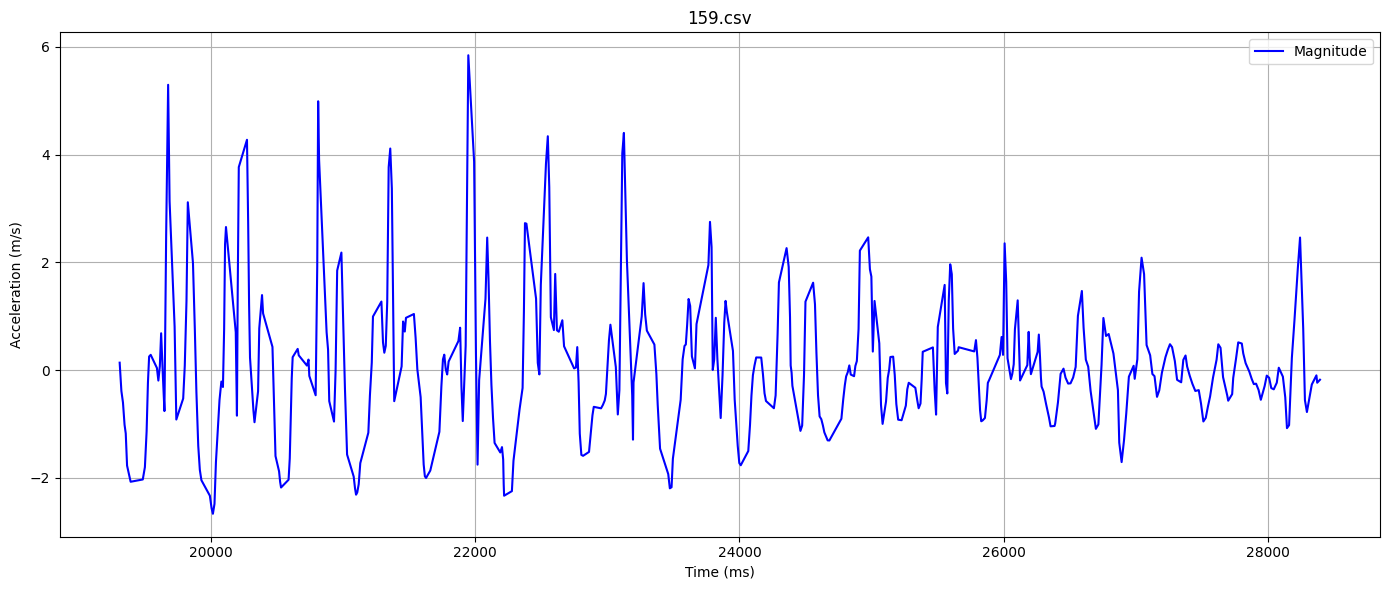

In [27]:
import matplotlib.pyplot as plt 

files_to_print = [f for f in os.listdir(mag_reduced_data_path) if (os.path.isfile(os.path.join(mag_reduced_data_path, f)) and os.path.splitext(os.path.join(mag_reduced_data_path, f))[1] == '.csv')]
files_to_print = files_to_print[:5]


for filename in files_to_print:
    csv_data = pd.read_csv(os.path.join(mag_reduced_data_path, filename)) 

    csv_data = csv_data[1000:2000]

    plt.figure(figsize=(14,6))

    plt.plot(csv_data['timestamp'], csv_data['magnitude'], label='Magnitude', color='b')

    plt.title(filename)
    plt.xlabel('Time (ms)')
    plt.ylabel('Acceleration (m/s)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Next, we apply a Kalman filter on this data to smoothe it out

In [28]:
from filterpy.kalman import KalmanFilter

def create_acc_kalman():
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = np.array([[0.], [0.]])
    kf.F = np.array([[1., 1.],
                     [0., 1.]])
    kf.H = np.array([[1., 0.]]) 
    kf.P *= 1000. 
    kf.R = 0.01
    kf.Q = np.array([[5e-5, 0.],
                     [0., 5e-5]])
    
    return kf

def update_kf_F(kf, dt):
    kf.F = np.array([[1., dt],
                     [0., 1.]])


In [29]:

files_to_update = [f for f in os.listdir(mag_reduced_data_path) if (os.path.isfile(os.path.join(mag_reduced_data_path, f)) and os.path.splitext(os.path.join(mag_reduced_data_path, f))[1] == '.csv')]


kalman_filtered_data_path = '../data/mendeley-Cristiana-Gabriel/updated_data_kalman_filtered'

for filename in files_to_update:
    csv_data = pd.read_csv(os.path.join(mag_reduced_data_path, filename)) 

    kf = create_acc_kalman()

    filtered = []
    for i in range(len(csv_data)):
        # Update the Kalman Filter matrix F
        if i > 0:
            dt = (csv_data['timestamp'].iloc[i] - csv_data['timestamp'].iloc[i-1]) / 1000
            update_kf_F(kf, dt)

        kf.predict()
        kf.update(csv_data['magnitude'].iloc[i])
        filtered.append(kf.x[0][0])

    csv_data['filtered'] = filtered

    csv_data.to_csv(os.path.join(kalman_filtered_data_path, filename), index=False)

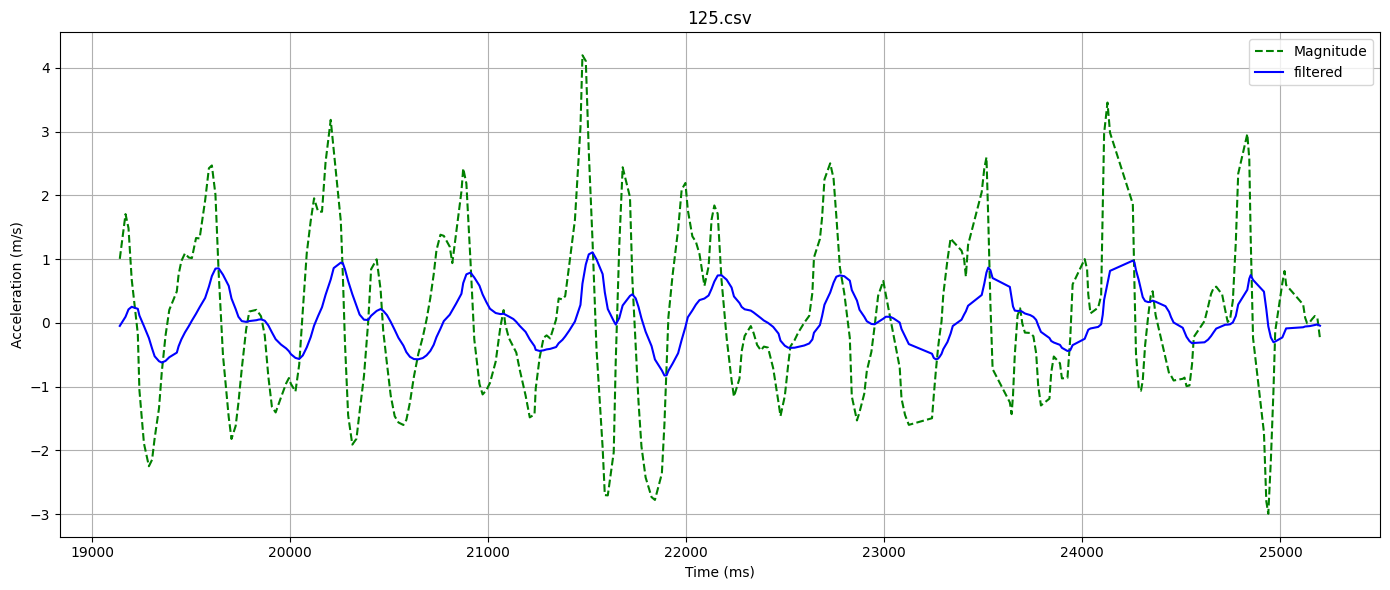

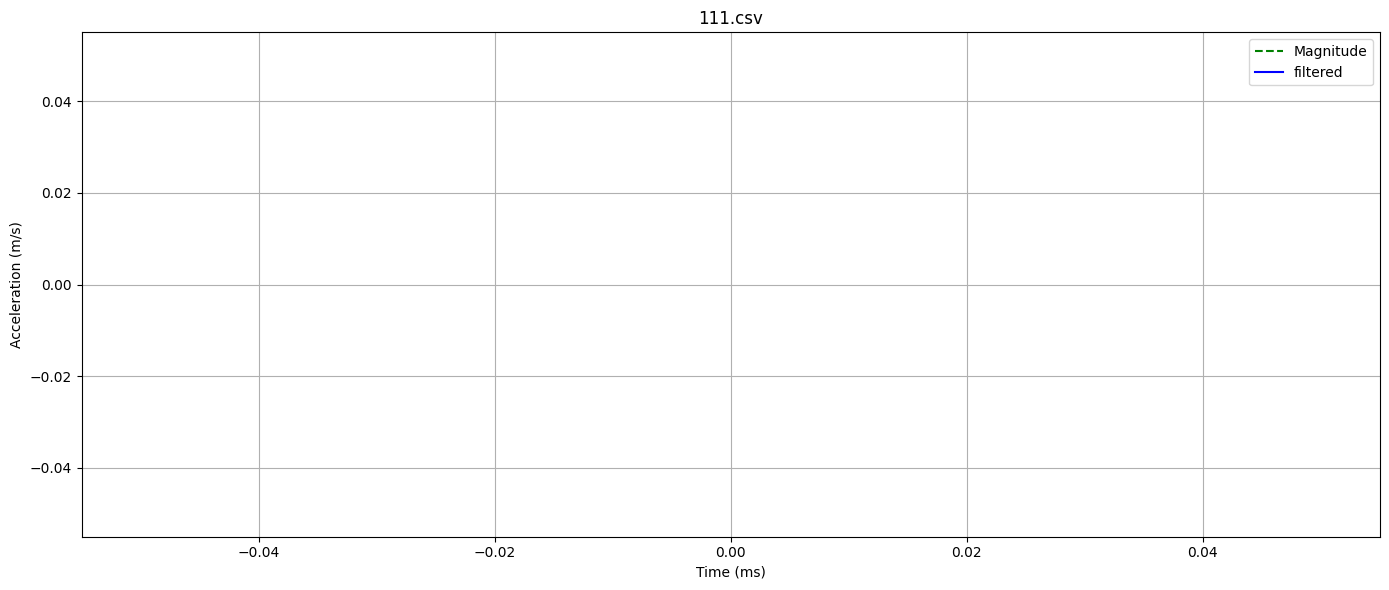

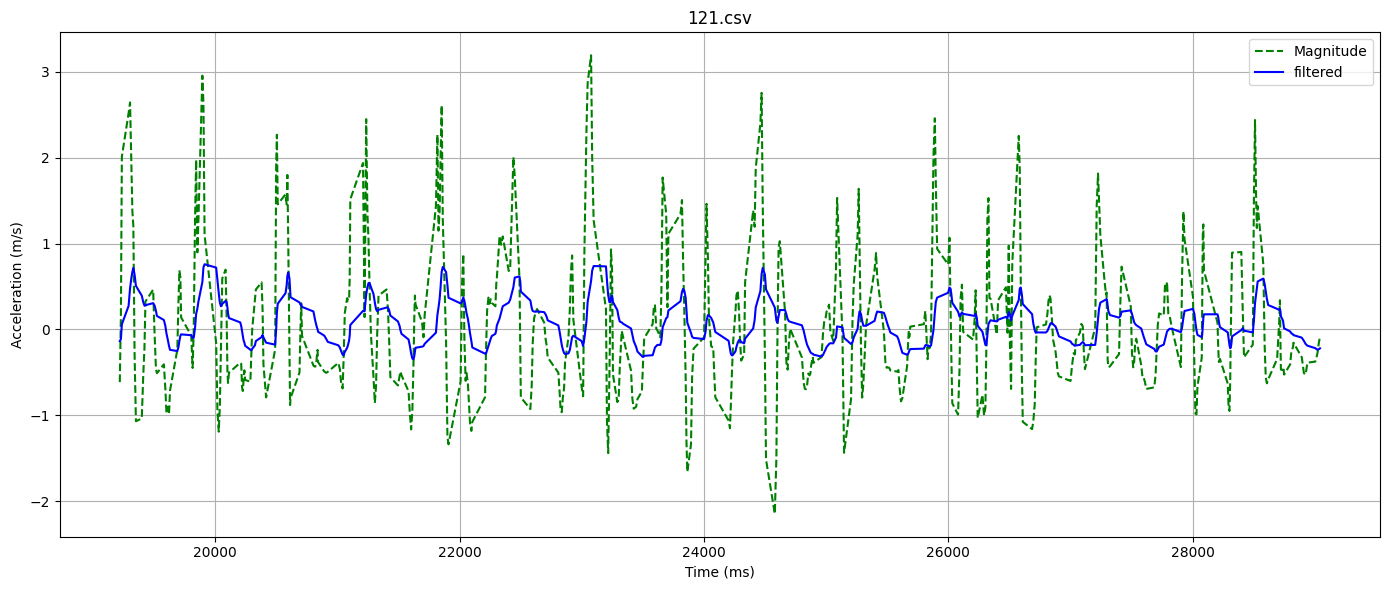

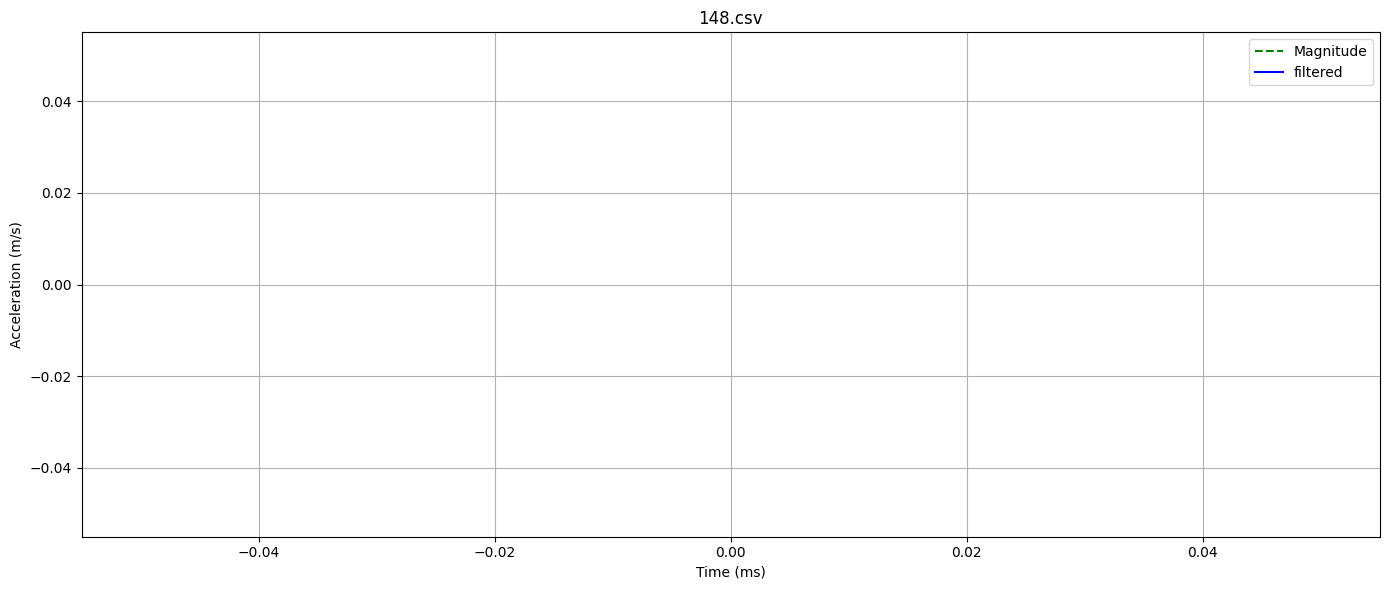

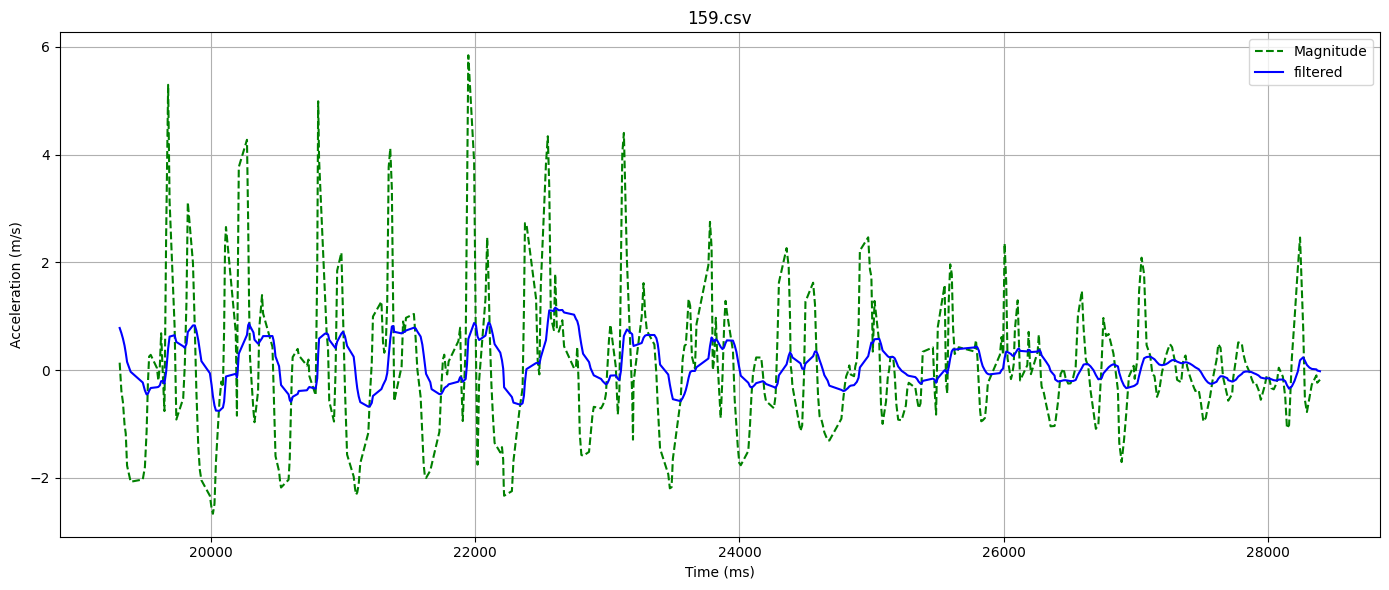

In [30]:
import matplotlib.pyplot as plt 

files_to_print = [f for f in os.listdir(kalman_filtered_data_path) if (os.path.isfile(os.path.join(kalman_filtered_data_path, f)) and os.path.splitext(os.path.join(kalman_filtered_data_path, f))[1] == '.csv')]
files_to_print = files_to_print[:5]


for filename in files_to_print:
    csv_data = pd.read_csv(os.path.join(kalman_filtered_data_path, filename)) 

    csv_data = csv_data[1000:2000]

    plt.figure(figsize=(14,6))

    plt.plot(csv_data['timestamp'], csv_data['magnitude'], label='Magnitude', color='g', linestyle='--')
    plt.plot(csv_data['timestamp'], csv_data['filtered'], label='filtered', color='b')

    plt.title(filename)
    plt.xlabel('Time (ms)')
    plt.ylabel('Acceleration (m/s)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Implement the step detection algorithm presented in the paper

In [31]:
def detect_steps(df, mag_col='filtered', time_col='timestamp', threshold=0.2, min_gap_ms = 200):

    mag = df[mag_col].values
    time = df[time_col].values

    peak_vector = []
    in_peak = False
    last_step_time = None

    df['peak'] = 0

    for i in range(len(mag)):
        c = mag[i]
        

        # If we’re above the threshold, add to peak vector
        if c > threshold:
            peak_vector.append({'mag': c, 'idx': i})
            in_peak = True
        elif in_peak:  # we just exited a peak
            if peak_vector:
                max_item = max(peak_vector, key=lambda item: item['mag']) 

                step_time = time[max_item['idx']]

                df.at[max_item['idx'], 'peak'] = 1
                # Apply temporal constraint
               # if last_step_time is None or (step_time - last_step_time) >= min_gap_ms:
                    # df.at[max_item['idx'], 'peak'] = 1
                    #last_step_time = step_time

            # Reset for next peak
            peak_vector = []
            in_peak = False

    return df
    


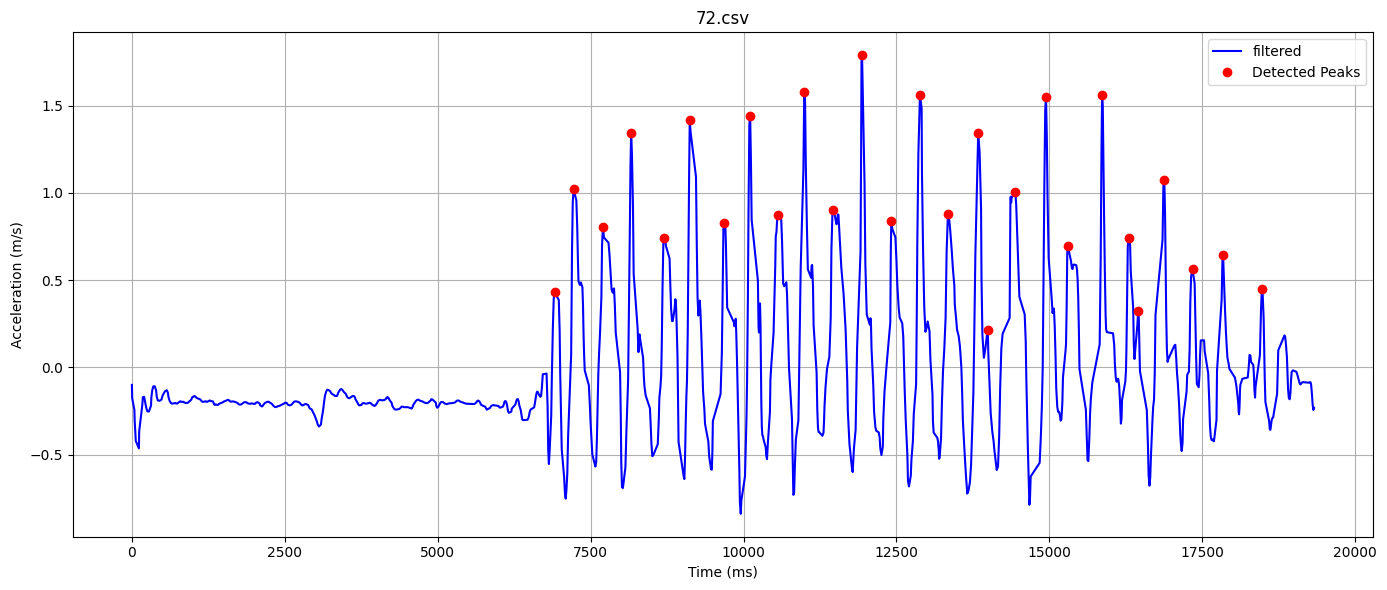

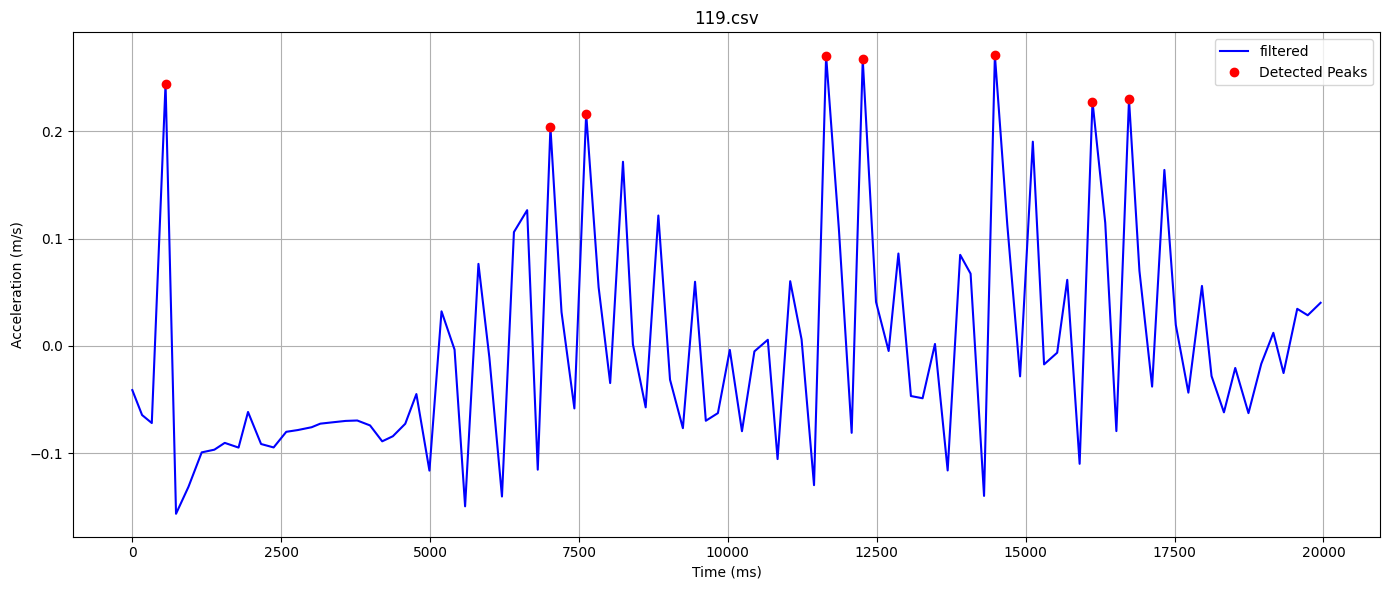

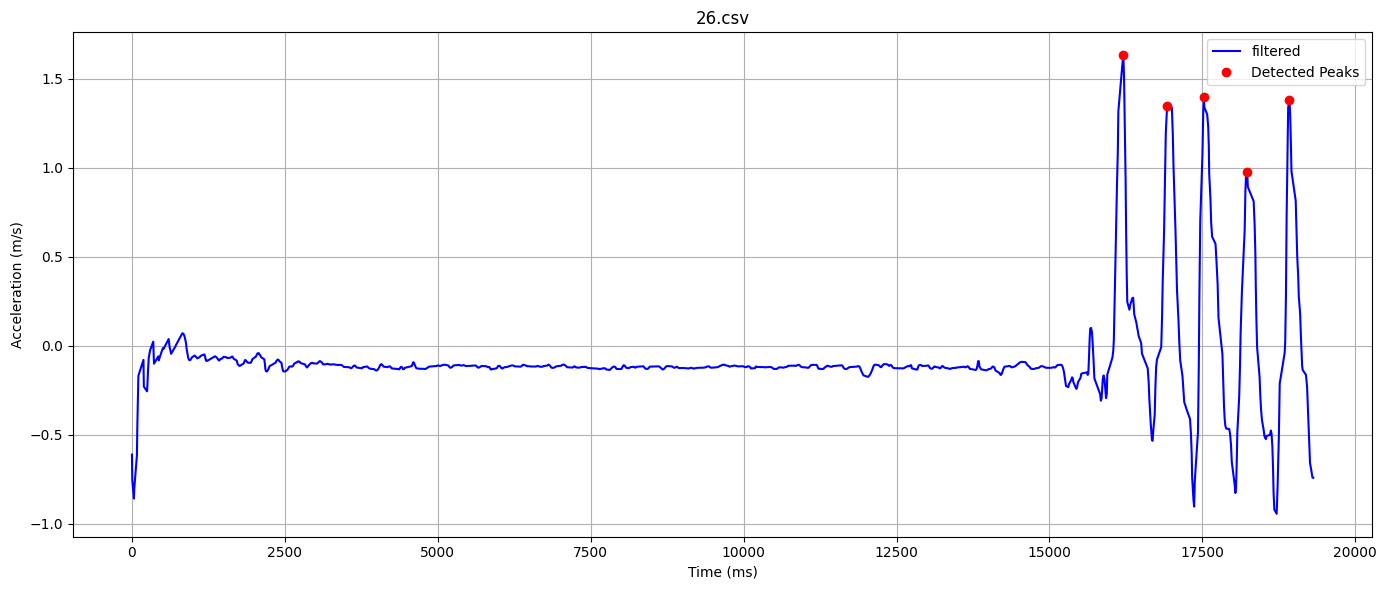

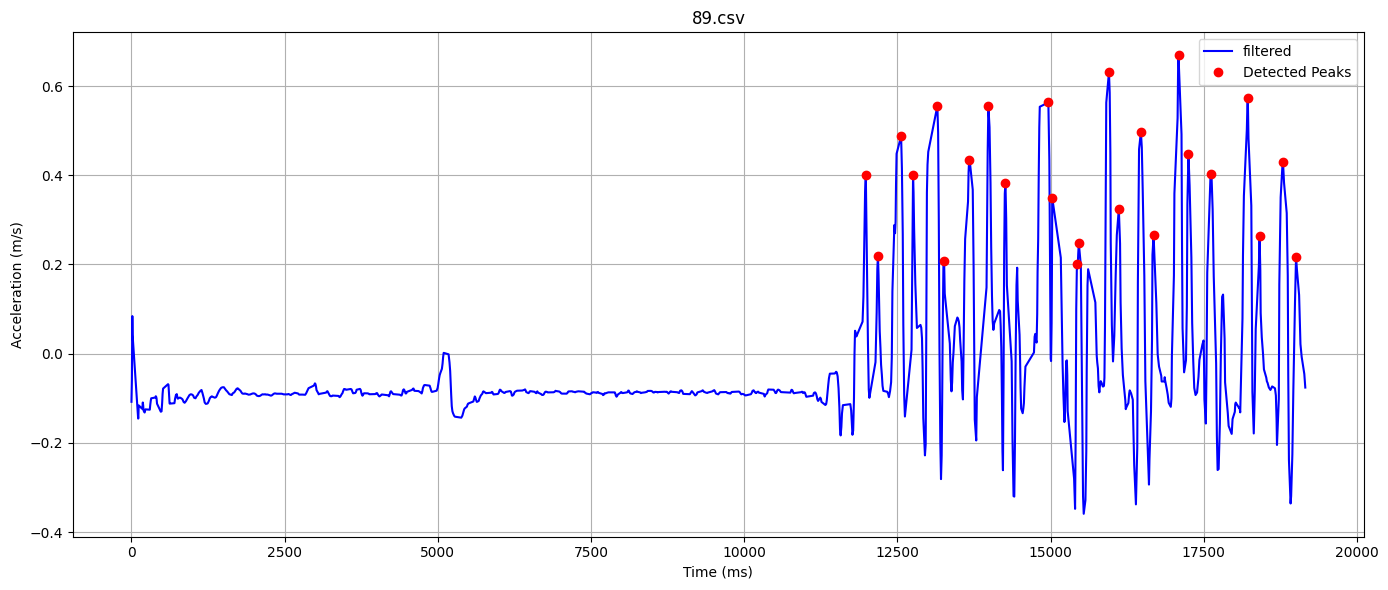

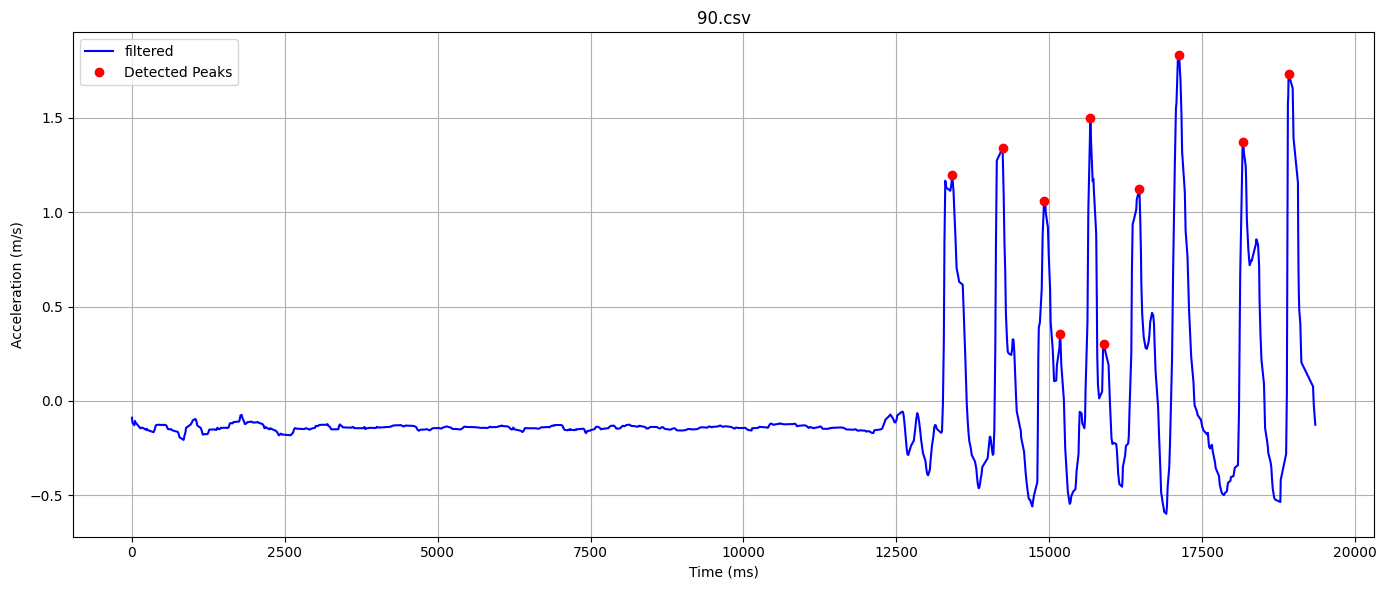

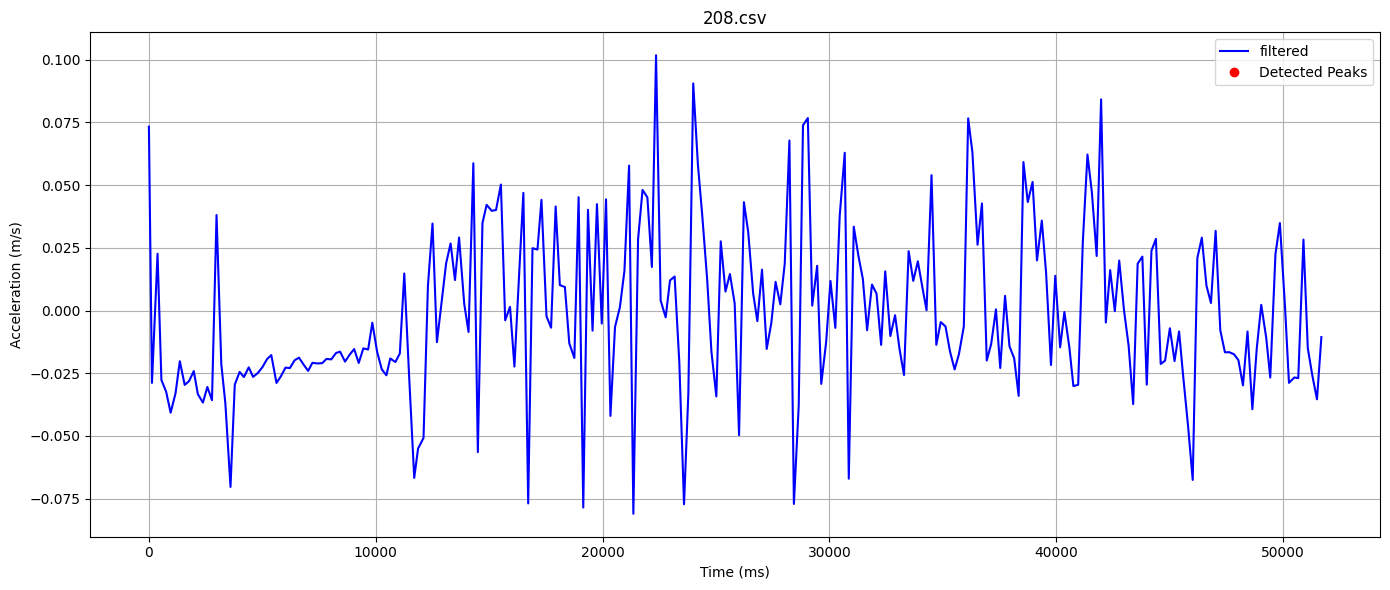

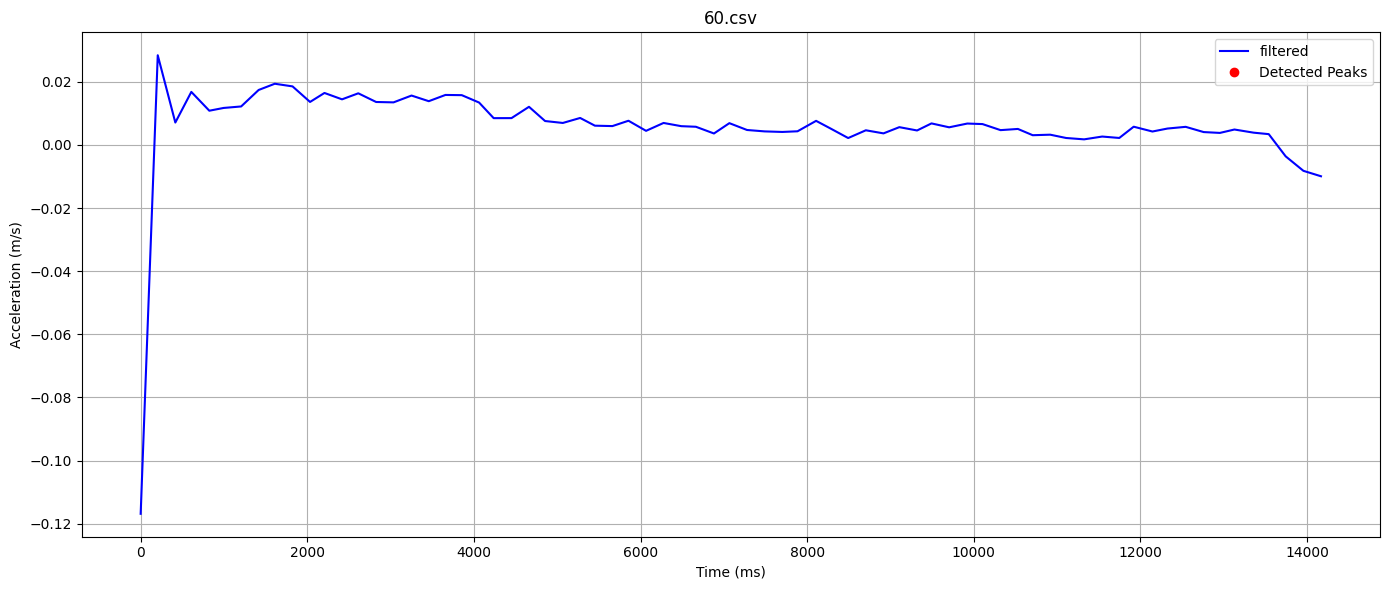

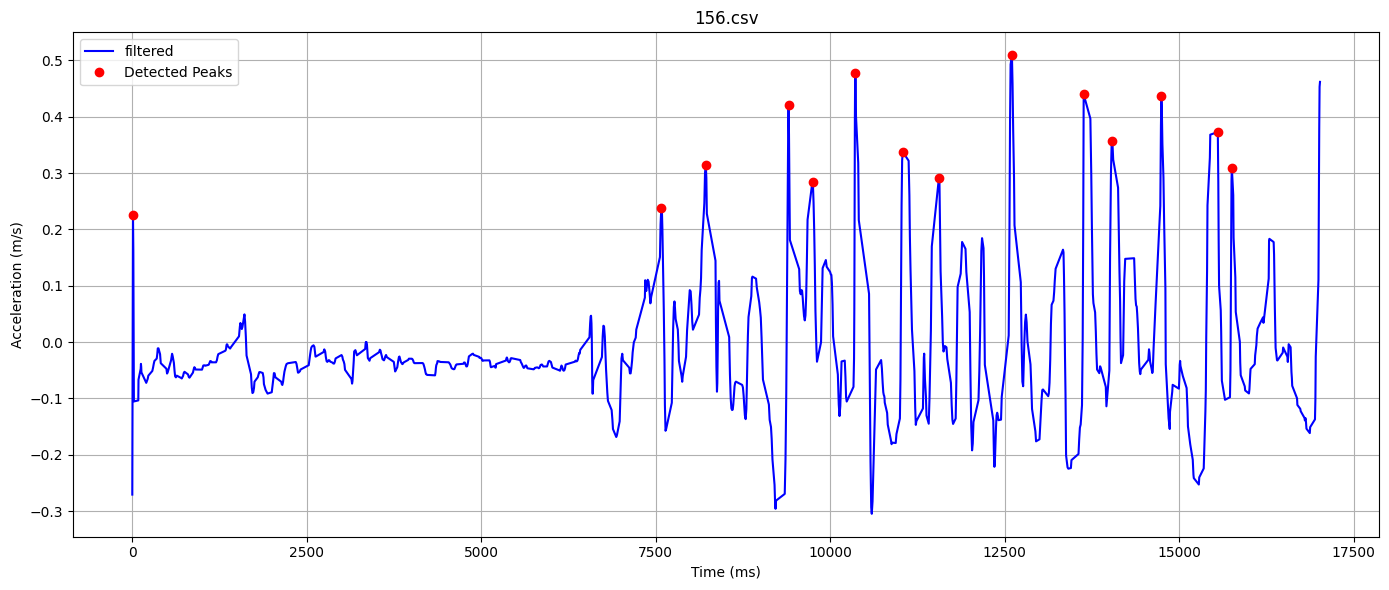

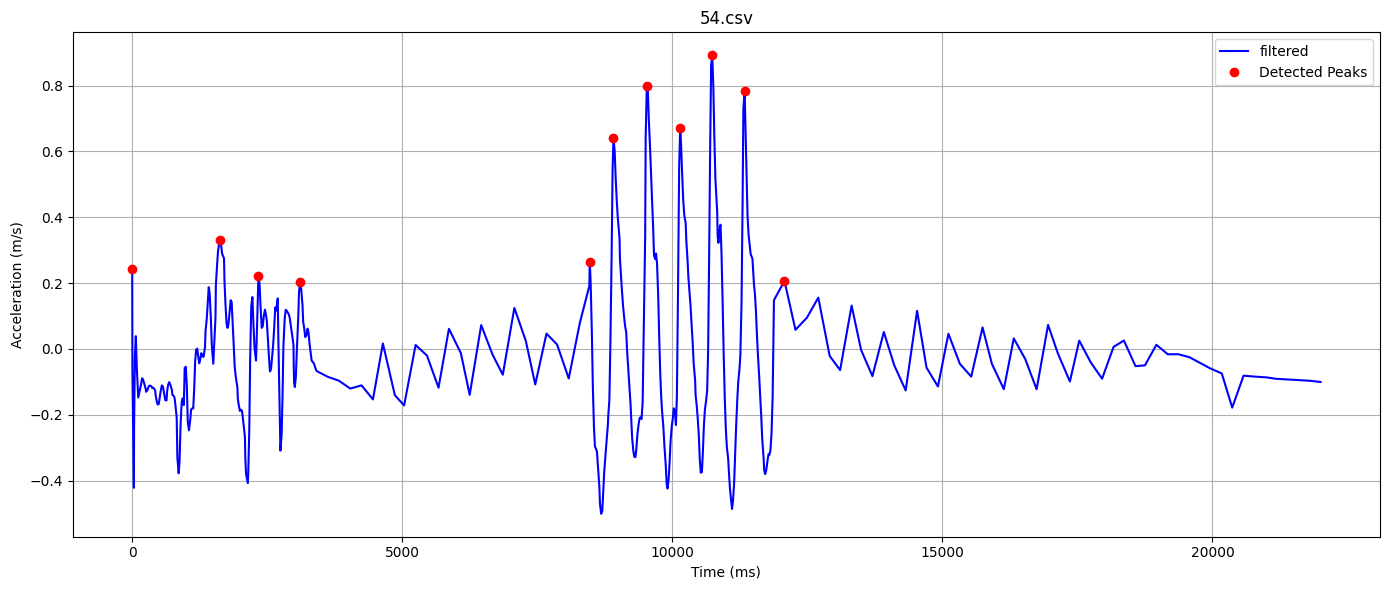

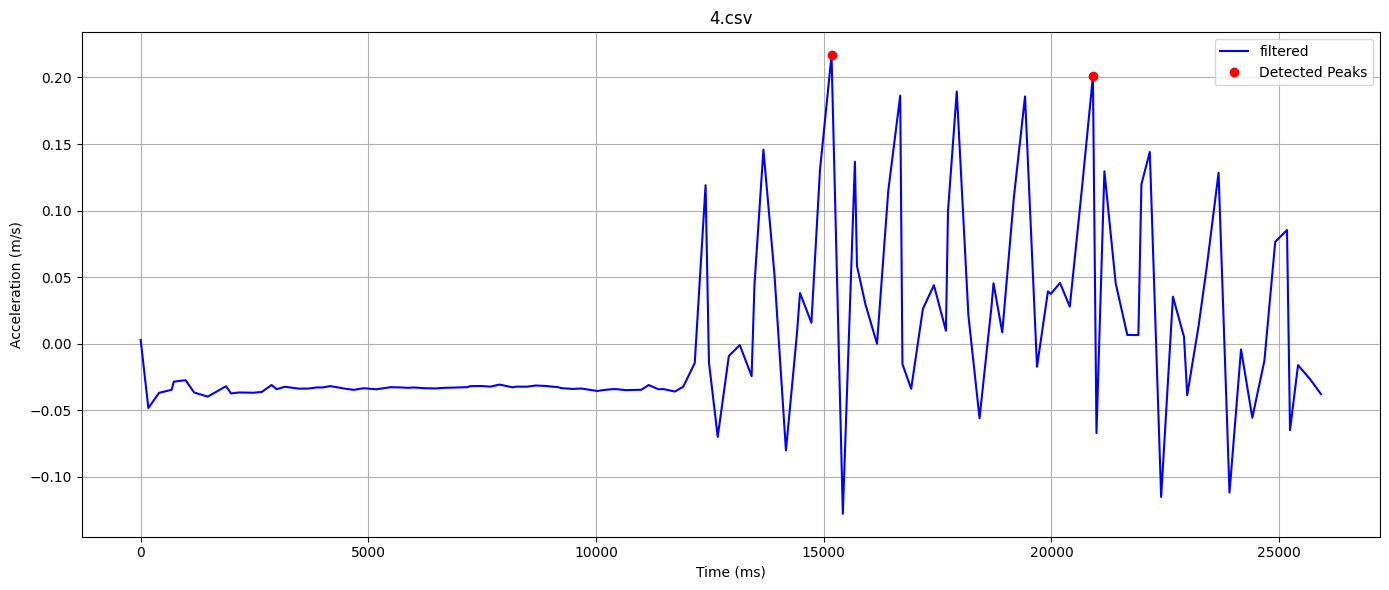

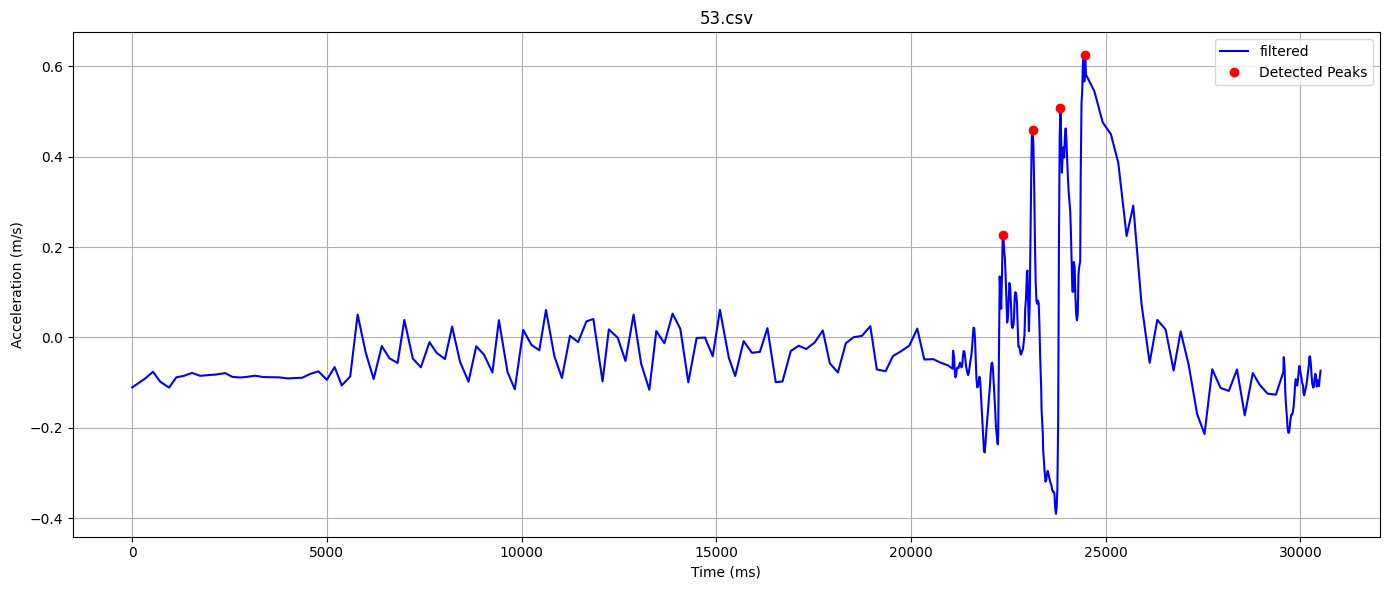

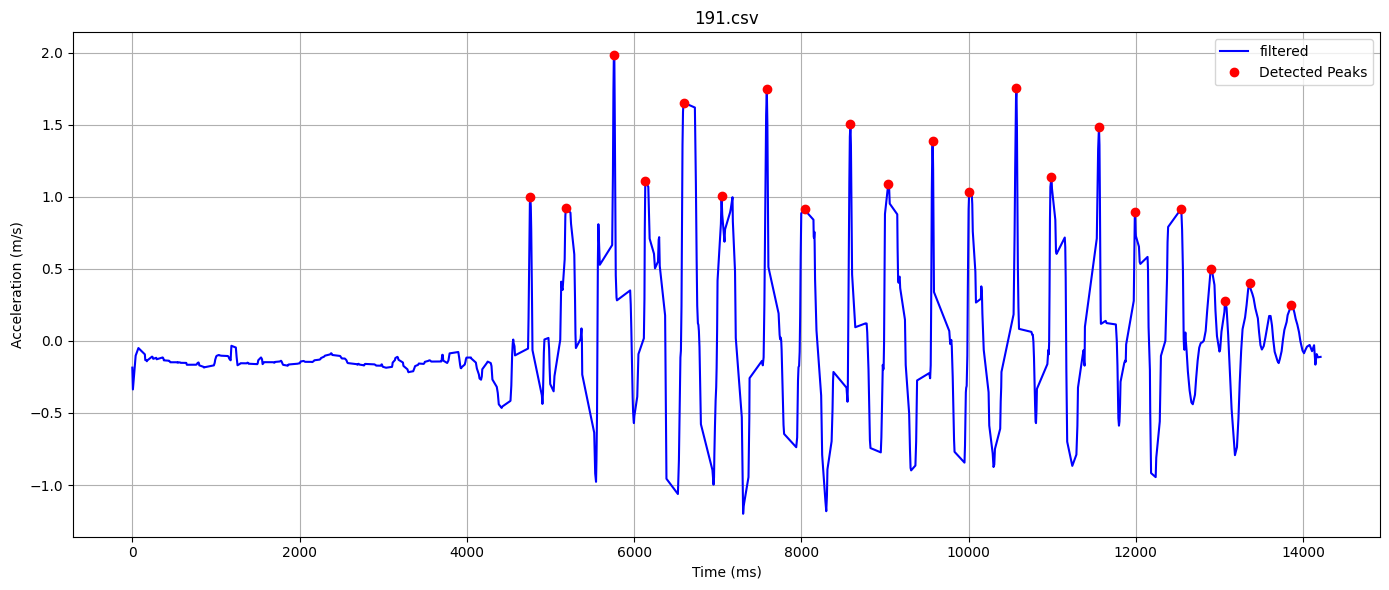

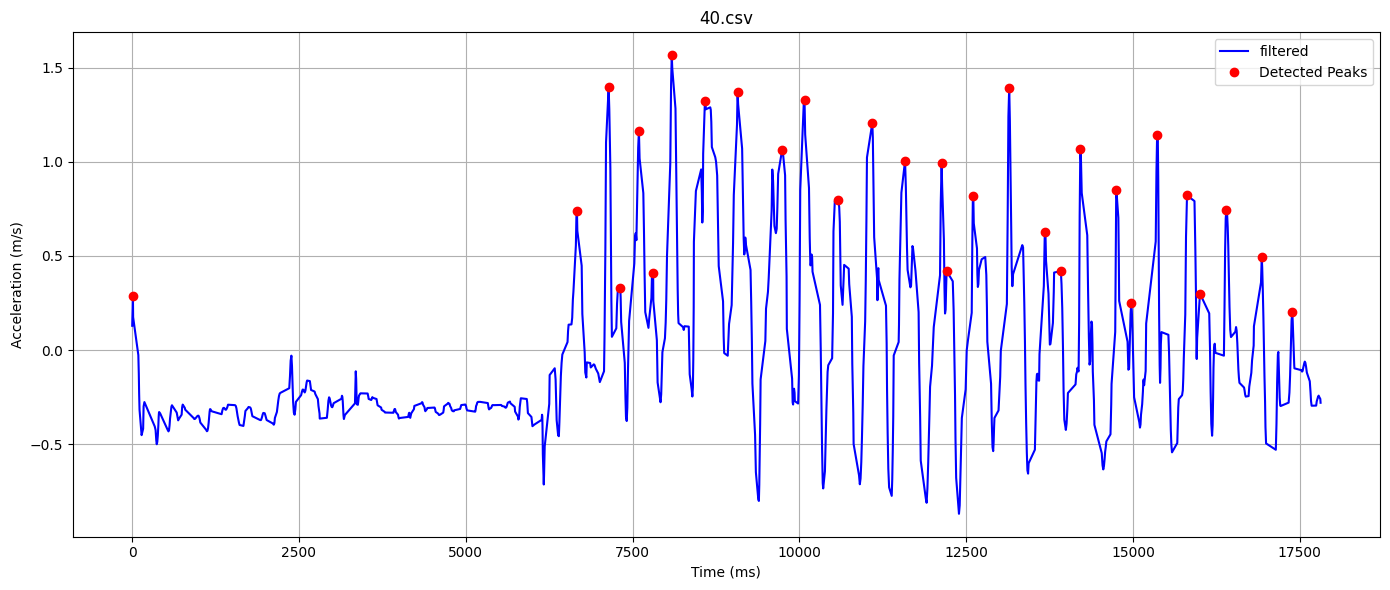

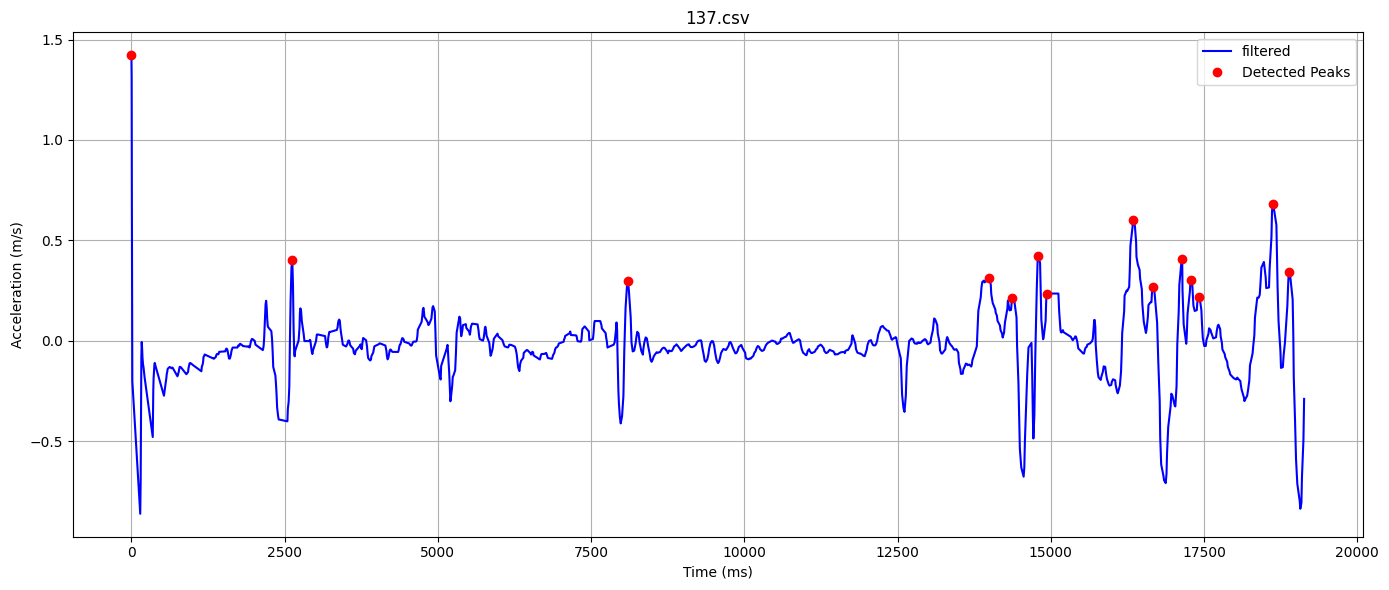

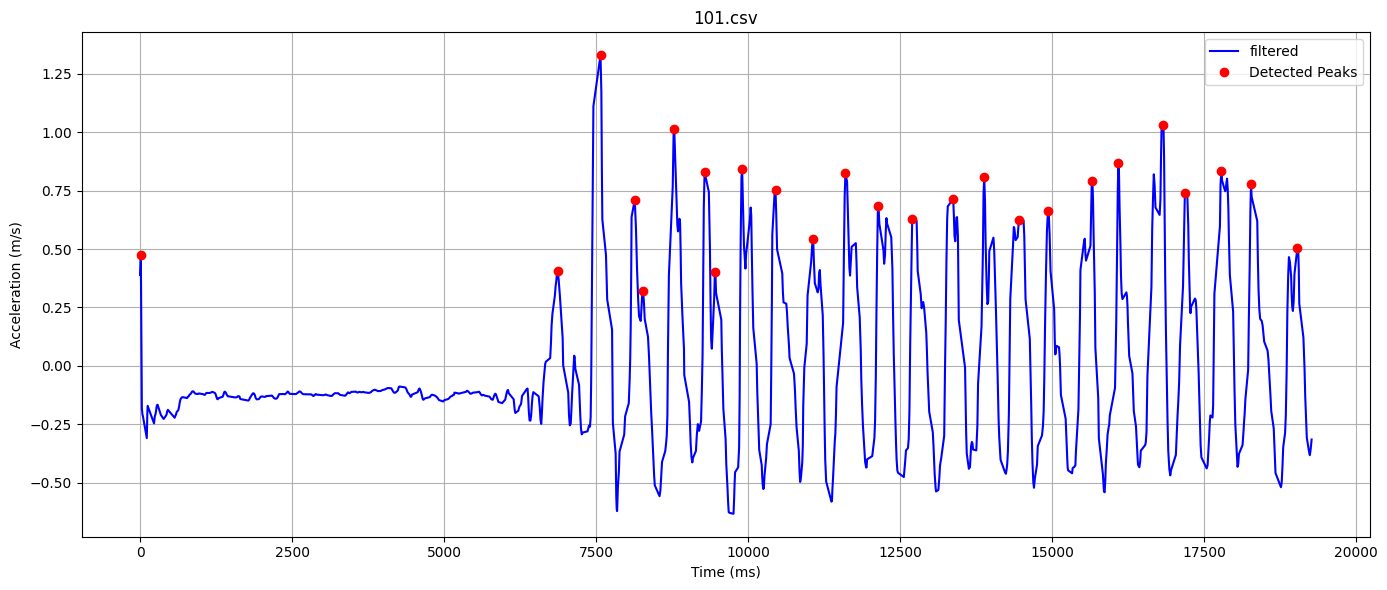

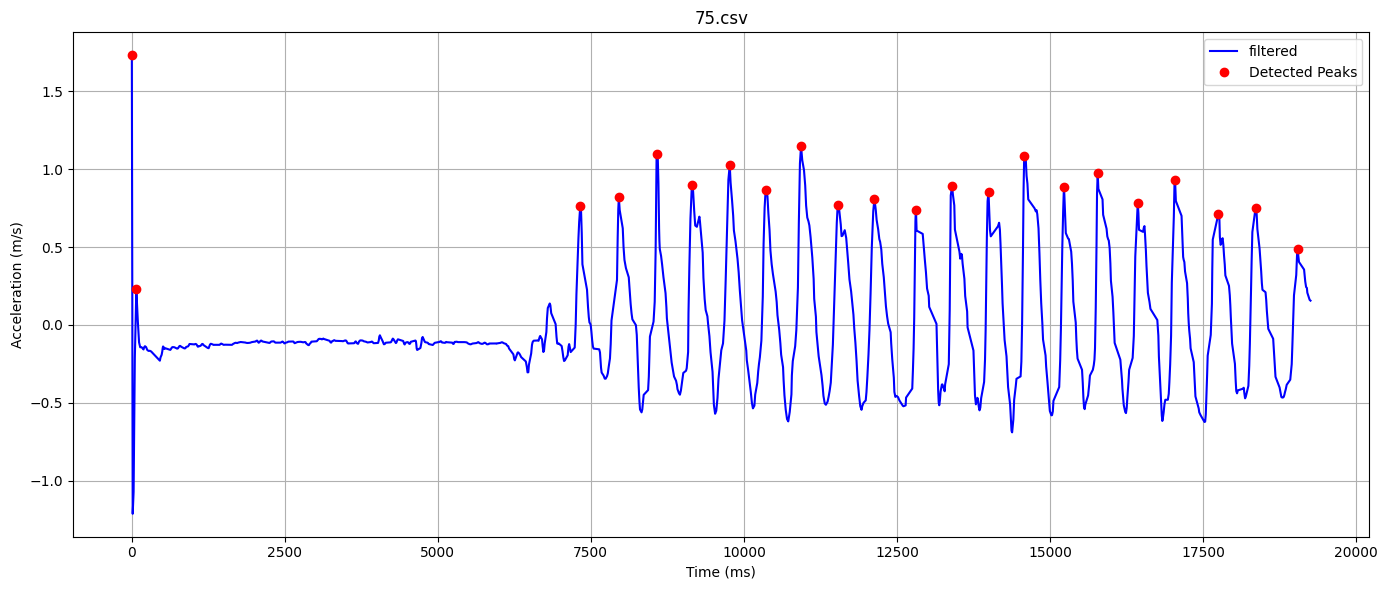

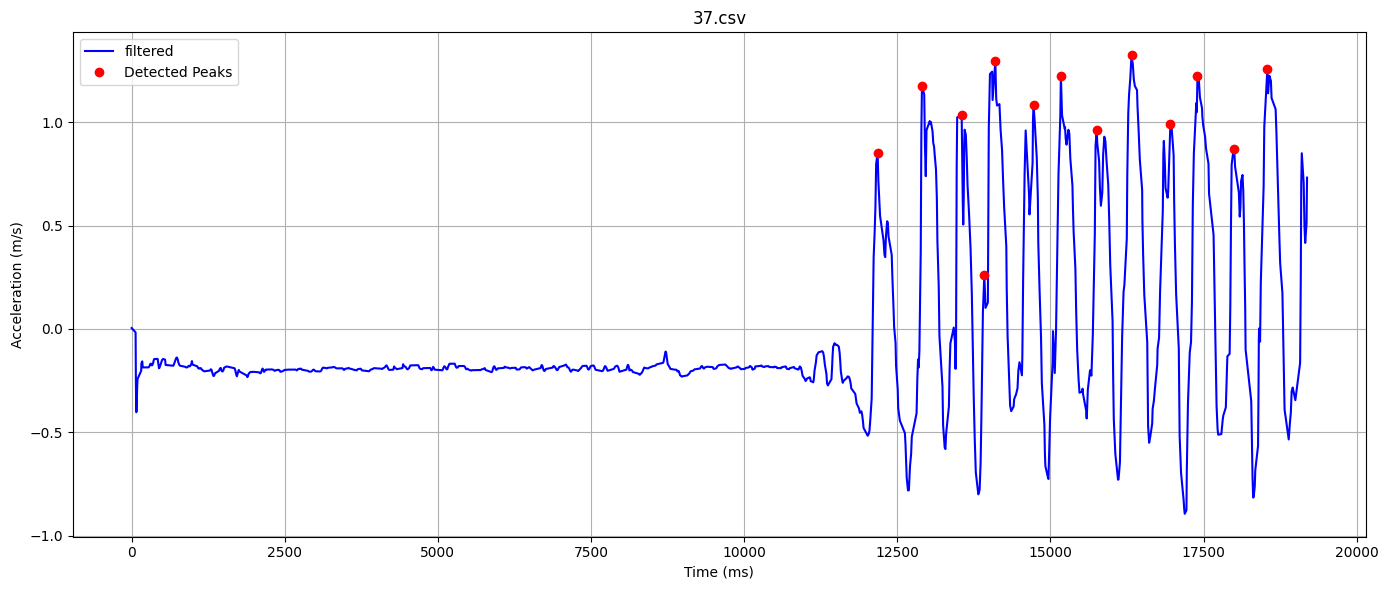

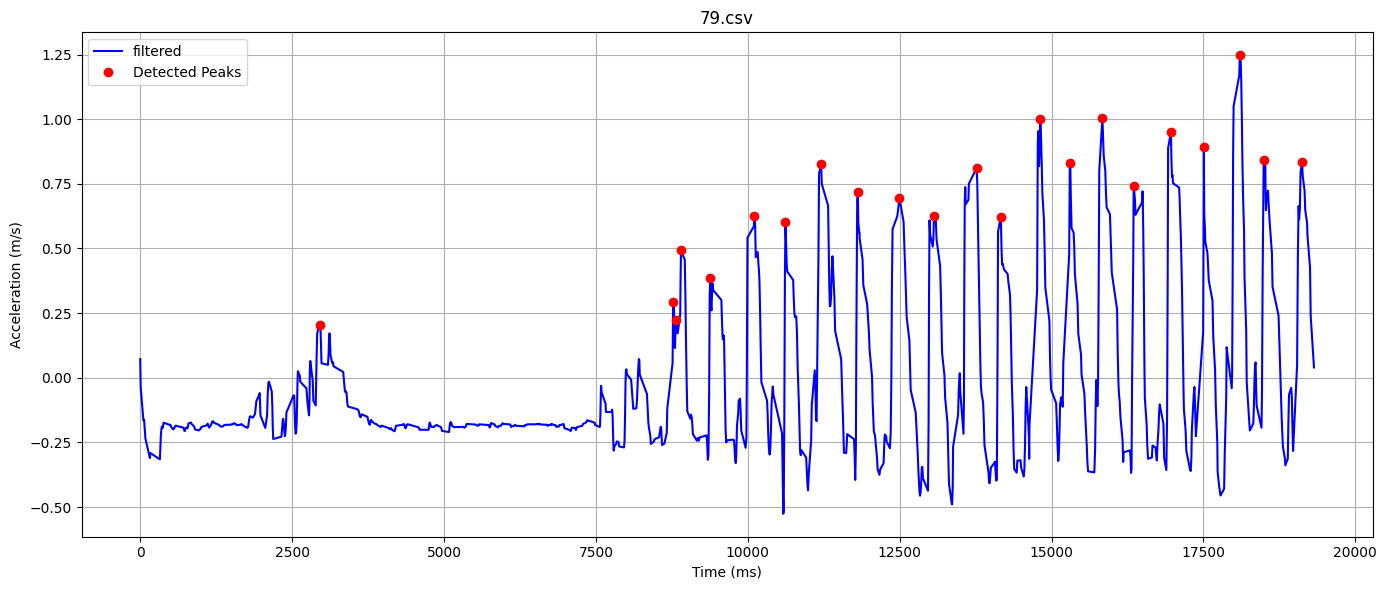

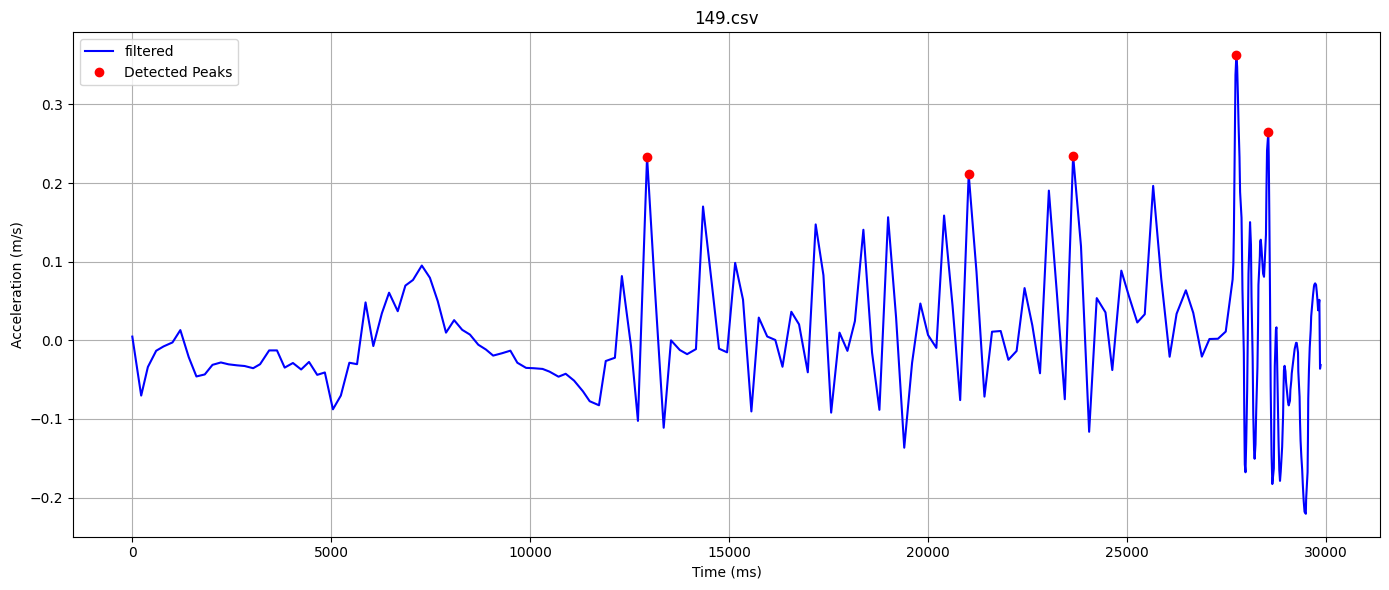

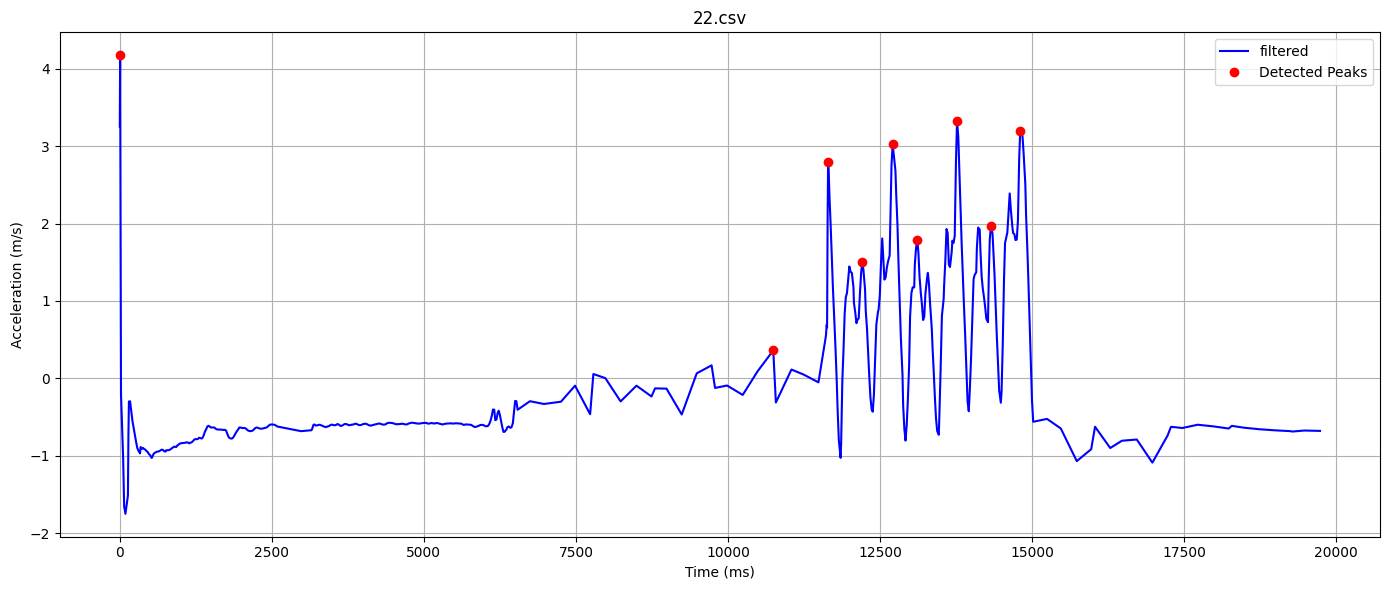

In [32]:
import os
import pandas as pd
import matplotlib.pyplot as plt

kalman_filtered_data_path = '../data/mendeley-Cristiana-Gabriel/updated_data_kalman_filtered'

files_to_update = [f for f in os.listdir(kalman_filtered_data_path) if (os.path.isfile(os.path.join(kalman_filtered_data_path, f)) and os.path.splitext(os.path.join(kalman_filtered_data_path, f))[1] == '.csv')]

files_to_update = files_to_update[5:25]


for filename in files_to_update:
    csv_data = pd.read_csv(os.path.join(kalman_filtered_data_path, filename)) 



    csv_data = detect_steps(csv_data)

    plt.figure(figsize=(14,6))

    plt.plot(csv_data['timestamp'][:1000], csv_data['filtered'][:1000], label='filtered', color='b')

    csv_data_peaks = csv_data[:1000]
    peaks = csv_data_peaks[csv_data_peaks['peak'] == 1]

    plt.plot(peaks['timestamp'], peaks['filtered'], 'o', color='r', label='Detected Peaks')

    plt.title(filename)
    plt.xlabel('Time (ms)')
    plt.ylabel('Acceleration (m/s)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()